# 06 - Model Evaluation & Comparison

**Objective:** Load the three trained models (baseline, compact_cnn, final) and compare their validation/test metrics, parameter counts, and sizes side by side, selecting the final model by VALIDATION metrics only.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


In [2]:
import json
baseline = json.load(open(ML_ROOT/'models'/'baseline'/'baseline_results.json'))
cnn = json.load(open(ML_ROOT/'models'/'compact_cnn'/'compact_cnn_metadata.json'))
final = json.load(open(ML_ROOT/'models'/'final'/'final_metadata.json'))

In [3]:
rows = []
rows.append(['baseline (LogReg+MFCC)', None, None,
             baseline['validation']['macro_f1'], baseline['test']['macro_f1'], baseline['external_test']['macro_f1']])
rows.append(['compact_cnn (Mel)', cnn['n_params'], cnn['weights_size_bytes'],
             cnn['validation_metrics']['macro_f1'], cnn['test_metrics']['macro_f1'], cnn['external_test_metrics']['macro_f1']])
rows.append(['final (depthwise-sep, Mel)', final['n_params'], final['weights_size_bytes'],
             final['validation_metrics']['macro_f1'], final['test_metrics']['macro_f1'], final['external_test_metrics']['macro_f1']])
comp = pd.DataFrame(rows, columns=['model','params','weights_bytes','val_macroF1','test_macroF1','ext_macroF1'])
comp

,model,params,weights_bytes,val_macroF1,test_macroF1,ext_macroF1
0,baseline (LogReg+MFCC),NaN,NaN,0.425084,0.359541,0.589857
1,compact_cnn (Mel),6147.0,24588.0,0.535808,0.328518,0.220671
2,"final (depthwise-sep, Mel)",1315.0,5260.0,0.654240,0.561099,0.579344


## Model selection

Selection uses **validation macro-F1 only** (test/external-test are reported once for the record, never used to pick a model).

In [4]:
best = comp.loc[comp['val_macroF1'].idxmax()]
print('Selected model (highest validation macro-F1):', best['model'])

Selected model (highest validation macro-F1): final (depthwise-sep, Mel)


## Per-class F1 / recall for the selected final model (test set)

Per-class F1: {'background': 0.7981530343007915, 'chainsaw': 0.4936086529006883, 'gunshot': 0.3915343915343915}
Per-class recall: {'background': 0.6793935991016283, 'chainsaw': 0.8508474576271187, 'gunshot': 0.8604651162790697}


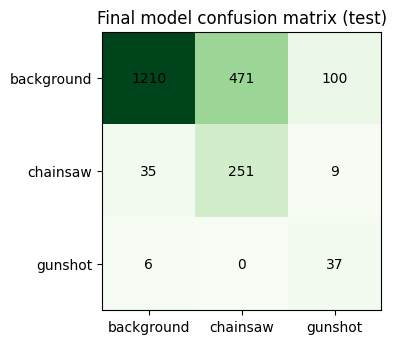

In [5]:
print('Per-class F1:', final['test_metrics']['per_class_f1'])
print('Per-class recall:', final['test_metrics']['per_class_recall'])
cm = np.array(final['test_metrics']['confusion_matrix'])
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(cm, cmap='Greens')
CLASSES=['background','chainsaw','gunshot']
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center')
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
ax.set_title('Final model confusion matrix (test)')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_final_model_confusion_matrix.png', dpi=120)
plt.show()

## Conclusion

The final depthwise-separable model has the highest validation macro-F1 among the three candidates and the smallest footprint (1,315 params, ~5KB FP32 weights), so it was selected as the deployment candidate for TFLite conversion (notebook 08).